# Deep Phishing - Análise Exploratória de Dados

Neste notebook, foi feito uma análise exploratória de dados do [dataset escolhido](https://archive.ics.uci.edu/dataset/967/phiusiil+phishing+url+dataset). A análise é essencial para entender a natureza do dataset, descobrindo se o dataset tem valores nulos ou outliers, e tratar tais casos antes do treinamento, entendendo a distribuição dos dados por meio de histogramas e gráficos de densidade, verificar se há desbalanceamento de classes, descobrir correlações entre múltiplicas features e redundâncias.


## Panorama geral do dataset

In [ ]:
import math
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import plot_tree
from sklearn.decomposition import PCA

binary_palette = sns.color_palette('tab10', 2)
sns.set_theme(style='whitegrid')

Começamos carregando o dataset e exibindo algumas de suas observações:

In [ ]:
csv_id = '1gbfFzWO0A13gcKCULvnwdPaoY-cUeqoN'
csv_url = f'https://drive.google.com/uc?export=download&id={csv_id}'

df = pd.read_csv(csv_url)
display(df)

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.000000,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.000000,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.000000,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.000000,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.000000,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235790,660997.txt,https://www.skincareliving.com,29,www.skincareliving.com,22,0,com,100.000000,1.000000,0.522907,...,1,0,1,51,7,21,187,2,191,1
235791,77185.txt,https://www.winchester.gov.uk,28,www.winchester.gov.uk,21,0,uk,100.000000,0.785714,0.028555,...,1,0,0,50,1,7,88,0,31,1
235792,622132.txt,https://www.nononsensedesign.be,30,www.nononsensedesign.be,23,0,be,100.000000,1.000000,0.003319,...,0,0,1,27,10,30,58,2,67,1
235793,7503962.txt,https://patient-cell-40f5.updatedlogmylogin.wo...,55,patient-cell-40f5.updatedlogmylogin.workers.dev,47,0,dev,28.157537,0.465116,0.000961,...,0,0,0,0,0,3,0,0,0,0


O dataset possui 235795 observações. Há 56 colunas, sendo a label a coluna que identifica se a URL é phishing ou não, e o FILENAME uma coluna que pode ser ignorada, restando assim 54 features.

As features descrevem algumas das características e métricas das páginas, como a própria na coluna URL, as várias características que são derivadas dela como por exemplo em Domain, DomainLength e TLD, e algumas características da página dessa URL como NoOfImage, NoOfCSS e NofOfJS.

In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation

None

Podemos observar que não há valores nulos e nem registros duplicados

In [ ]:
print('Nulos:', df.isnull().sum().sum())
print('Duplicados:', df.duplicated().sum())

Nulos: 0
Duplicados: 0


Portanto, não houve necessidade de preenchimento de valores ausentes ou tratamento de registros duplicados.

Podemos observar que das colunas, 51 são numéricas e 5 são categóricas.

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Colunas Numéricas: {len(num_cols)}")
print(f"Colunas Categóricas: {len(cat_cols)}")
print('--------')

card = df.nunique().sort_values()
print("Colunas e quantidades de valores únicos:")
display(card)

print("Métricas das variáveis numéricas:")
display(df[num_cols].describe())

print("Métricas das variáveis categóricas:")
display(df[cat_cols].describe())

Colunas Numéricas: 51
Colunas Categóricas: 5
--------
Colunas e quantidades de valores únicos:


,0
IsDomainIP,2
HasObfuscation,2
IsHTTPS,2
HasTitle,2
HasHiddenFields,2
HasSubmitButton,2
Bank,2
HasPasswordField,2
HasExternalFormSubmit,2
HasSocialNet,2


Métricas das variáveis numéricas:


,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


Métricas das variáveis categóricas:


,FILENAME,URL,Domain,TLD,Title
count,235795,235795,235795,235795,235795
unique,235795,235370,220086,695,197874
top,384822.txt,https://jauntyimprobableautomaticvectorization...,ipfs.io,com,0
freq,1,2,1197,112554,32719


## Análise da label

Ao verificar a distribuição da label para ter certeza de que não há desbalanceamento, podemos ver que há uma diferença de 14.4%, o que a princípio parece um desiquilíbrio muito leve para considerarmos.

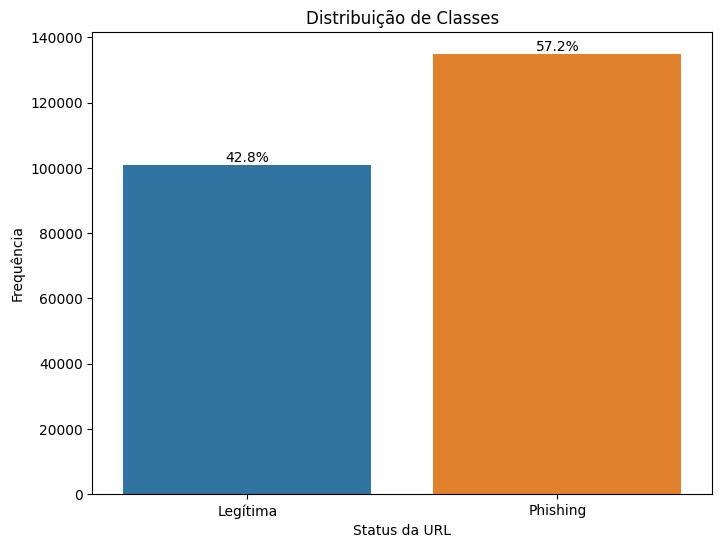

In [ ]:
plt.figure(figsize=(8,6))
ax = sns.countplot(data=df, x='label', hue='label', palette=binary_palette, legend=False)

total = len(df['label'])
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = f'{100 * height / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = height
        ax.annotate(percentage, (x, y), ha='center', va='bottom')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Legítima', 'Phishing'])

plt.title('Distribuição de Classes')
plt.xlabel('Status da URL')
plt.ylabel('Frequência')
plt.show()

## Matriz de correlação

Fazendo a matriz de correlação, podemos ter alguns insights acerca das features mais correlacionadas com a label, com coeficientes positivos altos indicando que a feature é associada a identificação de URLs de phishing, e coeficientes negativos indicando que a feature é associada a identificação de URLs legítimas.

Também podemos perceber a multicolinearidade entre diferentes features, que podem ser redundantes para o modelo.

Como o dataset contém muitas features, foi decidido realizar a matriz de correlação das mais relevantes em relação a label, com os 10 maiores coeficientes positivos e 5 menores coeficientes negativos.

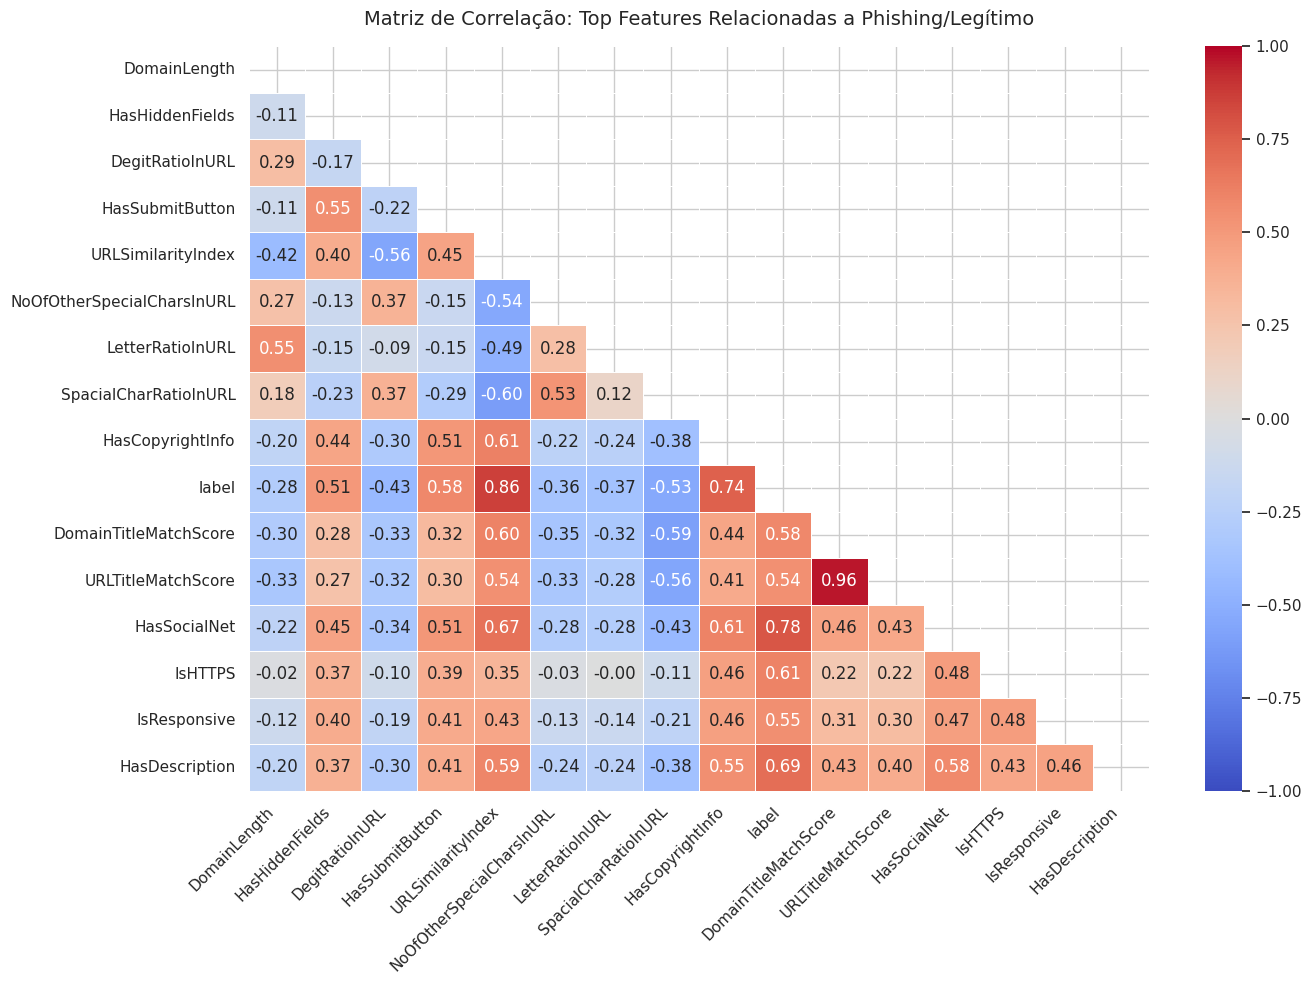

In [ ]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])
matriz_corr_completa = df_numeric.corr()
corr_com_label = matriz_corr_completa['label'].sort_values(ascending=False)
top_positivas = corr_com_label.head(11).index.tolist()
top_negativas = corr_com_label.tail(5).index.tolist()
features_selecionadas = list(set(top_positivas + top_negativas))
matriz_grafico = df_numeric[features_selecionadas].corr()
mascara = np.triu(np.ones_like(matriz_grafico, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(
    matriz_grafico,
    mask=mascara,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Matriz de Correlação: Top Features Relacionadas a Phishing/Legítimo', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
print("Correlação com a label:")
print(matriz_corr_completa['label'].sort_values(ascending=False))

Correlação com a label:
label                         1.000000
URLSimilarityIndex            0.860358
HasSocialNet                  0.784255
HasCopyrightInfo              0.743358
HasDescription                0.690232
IsHTTPS                       0.609132
DomainTitleMatchScore         0.584905
HasSubmitButton               0.578561
IsResponsive                  0.548608
URLTitleMatchScore            0.539419
HasHiddenFields               0.507731
HasFavicon                    0.493711
URLCharProb                   0.469749
CharContinuationRate          0.467735
HasTitle                      0.459725
Robots                        0.392620
NoOfJS                        0.373500
Pay                           0.359747
NoOfSelfRef                   0.316211
NoOfImage                     0.274658
LineOfCode                    0.272257
NoOfExternalRef               0.258627
NoOfiFrame                    0.225822
Bank                          0.188959
HasExternalFormSubmit         0.167574
H

Com isso, podemos identificar as features mais relacionadas a possibilidade de ser phishing:
- URLSimilarityIndex (0.86): feature mais relacionada, que mede o quão parecida a URL é com domínios legítimos conhecidos, mostrando que a maioria dos atacantes usam isso para a URL parecer com marcas famosas e enganar vítimas
- HasSocialNet (0.78), HasCopyrightInfo (0.74) e HasDescription (0.69): são relacionadas a respectivamente, presença de redes sociais vinculadas, informações de copyright e meta descrições, usadas provavelmente para obter a estrutura de sites reais para ganhar mais credibilidade técnica e visual
- IsHTTPS (0.61): indica que o uso de certificados SSL é bastante usado em URLs de phishing, indo de encontro com a crença de que sites HTTPS são automaticamente seguros

Nos indicadores de sites legítimos, temos:
- SpecialCharRationInURL (-0.53) e DegitRatioInURL (-0.43): proporções altas de caracteres especiais e dígitos tem uma relação negativa ao phishing
- LetterRatioInURL (-0.37), DomainLenght (-0.28) e URLLength (-0.23): indicam que o comprimento do domínio e de URLs maiores, assim como taxas maiores de letras, indicam uma menor incidência de sites serem phishing

Também identificamos algumas colinearidades:
- DomainTitleMatchScore e URLTitleMatchScore (0.96)
- HasSocialNet e HasCopyrightInfo (0.61)
- HasSocialNet e URLSimilarityIndex (0.67)